In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [33]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns='Chance of Admit ')
y = df['Chance of Admit ']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
X_train = MinMaxScaler().fit_transform(X_train)
X_test = MinMaxScaler().fit_transform(X_test)

In [47]:
model = Sequential()
model.add(Dense(12,activation='sigmoid',input_dim=8))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249 (996.00 B)

 Trainable params: 249 (996.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(loss='mean_squared_error',optimizer='Adam',metrics=['r2_score'])

In [50]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3290 - r2_score: -16.0947 - val_loss: 0.2746 - val_r2_score: -11.0446
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2189 - r2_score: -10.3714 - val_loss: 0.1787 - val_r2_score: -6.8366
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1368 - r2_score: -6.1088 - val_loss: 0.1098 - val_r2_score: -3.8163
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0808 - r2_score: -3.1977 - val_loss: 0.0654 - val_r2_score: -1.8676
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0463 - r2_score: -1.4031 - val_loss: 0.0399 - val_r2_score: -0.7483
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0280 - r2_score: -0.4550 - val_loss: 0.0266 - val_r2_score: -0.1655
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0191 - r2_score: 0.0069 - val_loss: 0.0209 - val_r2_score: 0.0828
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0162 - r2_score: 0.1609 - v

In [51]:
from sklearn.metrics import r2_score
r2_score(y_test,model.predict(X_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


0.7271662002694557

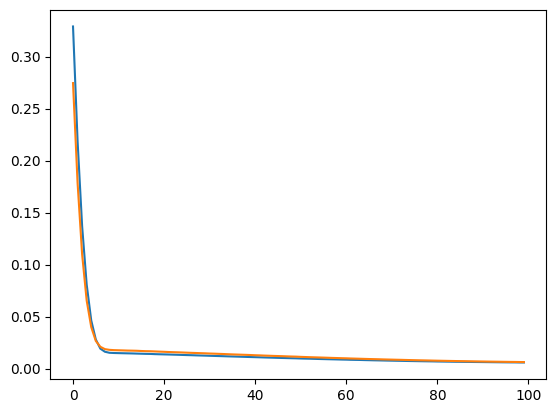

In [52]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

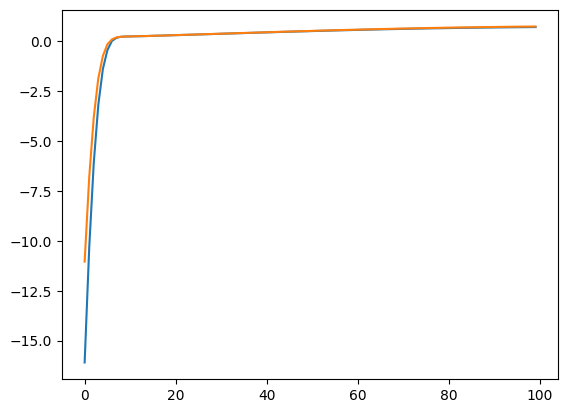

In [55]:
import matplotlib.pyplot as plt
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])
plt.show()